1. Імпорт та завантаження даних (згідно інструкції "Import the dataset into your code" на самомуж сайті)

Обрав датасет Credit Approval так як він один з небагатьох, який містить всі необхідні Feature Type а також має Missing Values

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

sns.set_theme(style="whitegrid", palette="muted")

credit_approval = fetch_ucirepo(id=27)

df = credit_approval.data.features.copy()
df['Target'] = credit_approval.data.targets

print(f"Розмір датасету: {df.shape}")
df.head()

Розмір датасету: (690, 16)


,A15,A14,A13,A12,A11,A10,A9,A8,A7,A6,A5,A4,A3,A2,A1,Target
0,0,202.0,g,f,1,t,t,1.25,v,w,g,u,0.000,30.83,b,+
1,560,43.0,g,f,6,t,t,3.04,h,q,g,u,4.460,58.67,a,+
2,824,280.0,g,f,0,f,t,1.50,h,q,g,u,0.500,24.50,a,+
3,3,100.0,g,t,5,t,t,3.75,v,w,g,u,1.540,27.83,b,+
4,0,120.0,s,f,0,f,t,1.71,v,w,g,u,5.625,20.17,b,+


2. Data Cleaning
Очищення даних реалізується через заміну символів '?' на системні NaN, примусову конвертацію визначених стовпців у числовий формат через pd.to_numeric та одноетапне заповнення всіх пропусків за допомогою словника, який містить розраховані медіани для числових ознак і моди для категоріальних

In [8]:
df = df.replace('?', np.nan)

numeric_cols = ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

print("Пропущені значення ДО очищення (стовпець: кількість):")
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0])
print("-" * 40)

medians = df.select_dtypes(include=['float64', 'int64']).median()

modes = df.select_dtypes(exclude=['float64', 'int64']).mode().iloc[0]

fill_values = {**medians.to_dict(), **modes.to_dict()}
df = df.fillna(value=fill_values)

print("Загальна кількість пропусків ПІСЛЯ очищення:", df.isnull().sum().sum())

Пропущені значення ДО очищення (стовпець: кількість):
A14    13
A7      9
A6      9
A5      6
A4      6
A2     12
A1     12
dtype: int64
----------------------------------------
Загальна кількість пропусків ПІСЛЯ очищення: 0


3. Графік залежності двох атрибутів

Побудова діаграми розсіювання (scatterplot) за допомогою бібліотеки Seaborn для відображення кореляції між двома безперервними атрибутами A3 та A8, де поділ за цільовим класом реалізовано через параметр hue

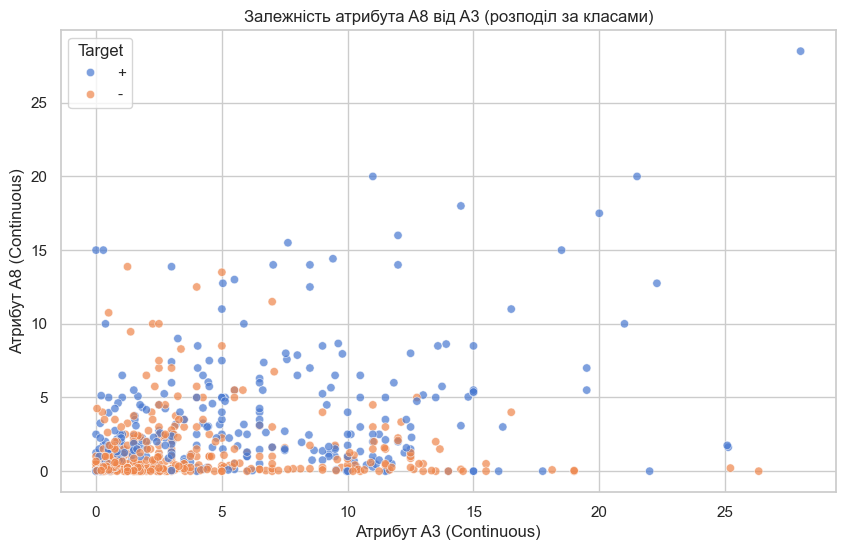

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='A3', y='A8', hue='Target', alpha=0.7)
plt.title('Залежність атрибута A8 від A3 (розподіл за класами)')
plt.xlabel('Атрибут A3 (Continuous)')
plt.ylabel('Атрибут A8 (Continuous)')
plt.show()

4. Гістограма з 5 заданими діапазонами

Дискретизація атрибута A15 шляхом розбиття його на п'ять кастомних діапазонів за допомогою функції pd.cut та побудова стовпчастої діаграми (countplot), де за допомогою циклу автоматично розраховуються та додаються текстові підписи з точною кількістю записів над кожним стовпцем

C:\Users\Admin\AppData\Local\Temp\ipykernel_5200\2469099507.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='A15_bins', palette='viridis')


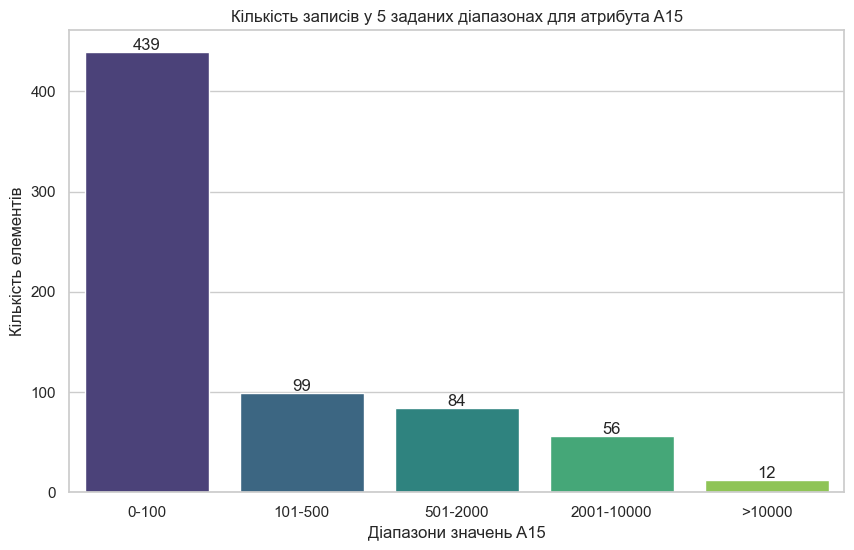

In [10]:
plt.figure(figsize=(10, 6))

custom_bins = [0, 100, 500, 2000, 10000, df['A15'].max()]
labels = ['0-100', '101-500', '501-2000', '2001-10000', '>10000']

df['A15_bins'] = pd.cut(df['A15'], bins=custom_bins, labels=labels, include_lowest=True)

ax = sns.countplot(data=df, x='A15_bins', palette='viridis')
plt.title('Кількість записів у 5 заданих діапазонах для атрибута A15')
plt.xlabel('Діапазони значень A15')
plt.ylabel('Кількість елементів')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

5. Багатовимірна візуалізація

Розрахунок матриці кореляцій для числових атрибутів з її візуалізацією через теплову карту (heatmap), а також побудова графіка попарного розподілу (pairplot) для обраної підмножини ознак, що дозволяє оцінити їхні багатовимірні залежності та ядерну оцінку щільності на діагоналі.

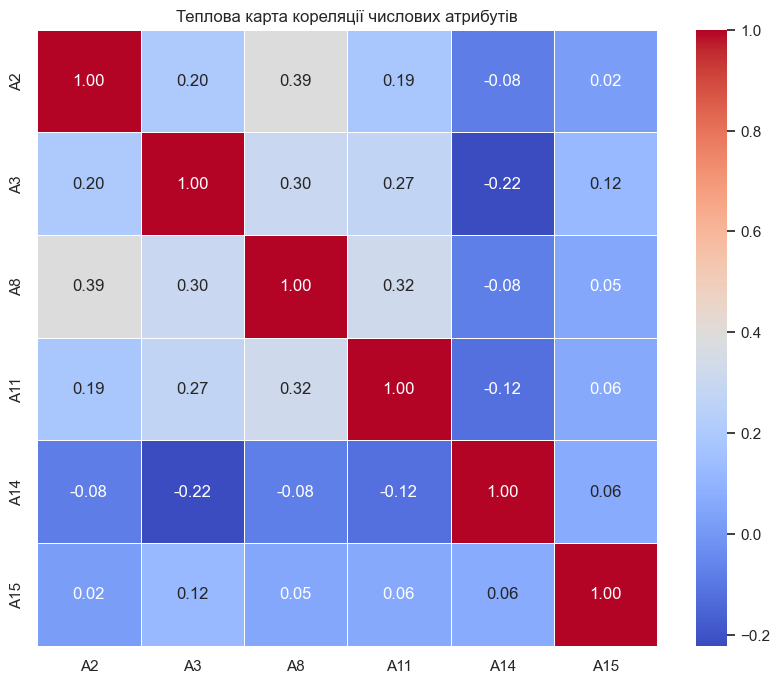

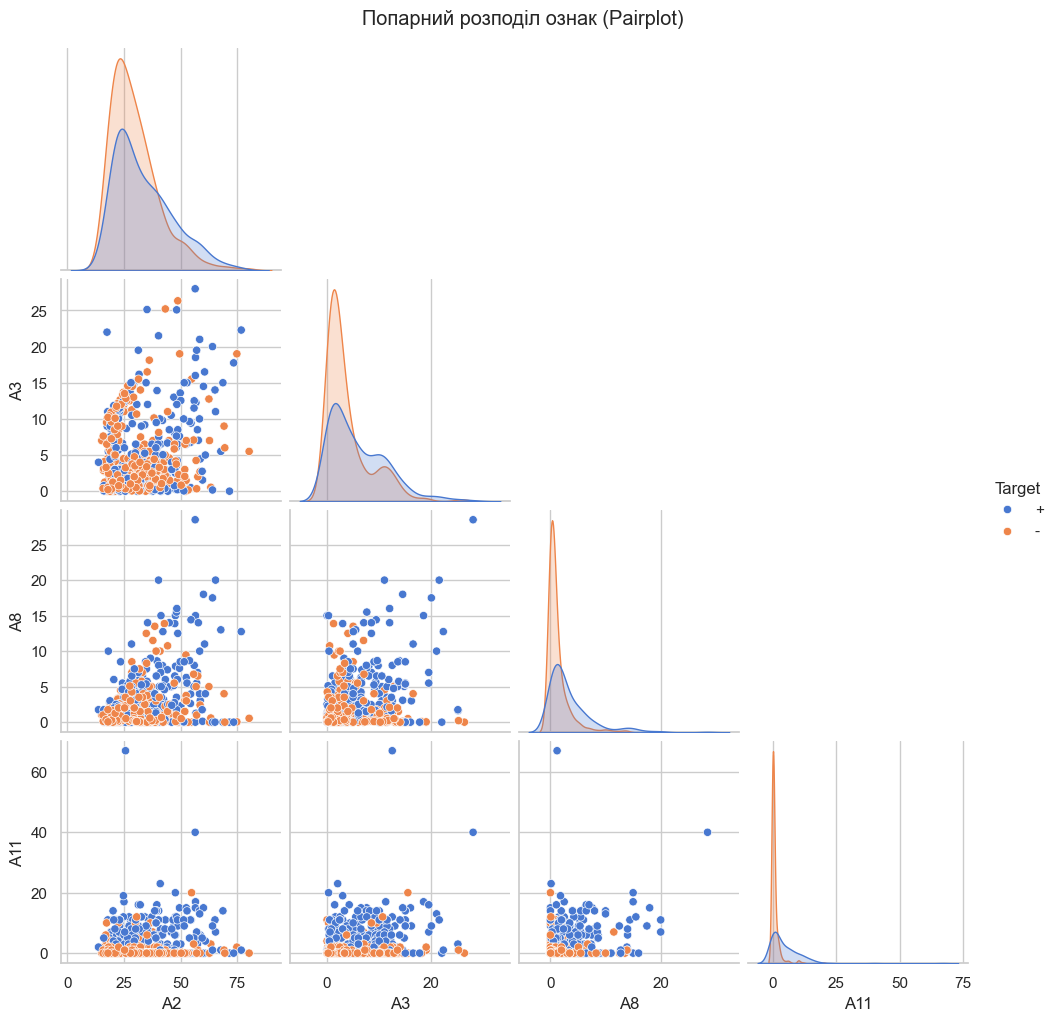

In [11]:
plt.figure(figsize=(10, 8))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Теплова карта кореляції числових атрибутів')
plt.show()

subset_cols = ['A2', 'A3', 'A8', 'A11', 'Target']
sns.pairplot(df[subset_cols], hue='Target', diag_kind='kde', corner=True)
plt.suptitle('Попарний розподіл ознак (Pairplot)', y=1.02)
plt.show()

6. Додаткові інформативні графіки

Розширений аналіз даних, що включає стовпчасту діаграму для перевірки збалансованості цільової змінної, діаграму розмаху (boxplot) для пошуку статистичних викидів в атрибуті A2 та застосування об'єкта FacetGrid з kdeplot для аналізу розподілу щільності ознаки A11 одночасно за кількома категоріями

C:\Users\Admin\AppData\Local\Temp\ipykernel_5200\467869190.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Target', palette='pastel')


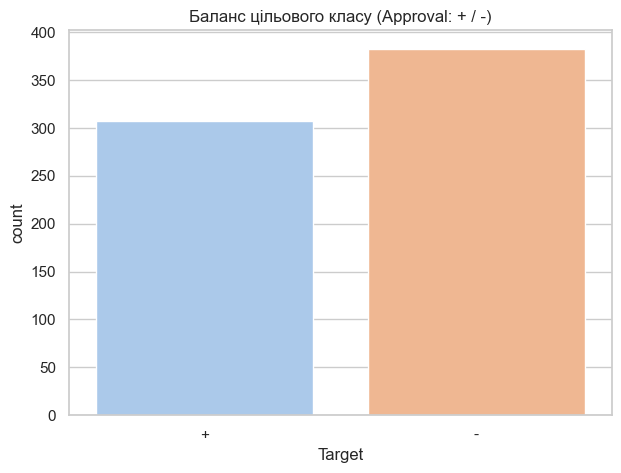

C:\Users\Admin\AppData\Local\Temp\ipykernel_5200\467869190.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y='A2', palette='Set2')


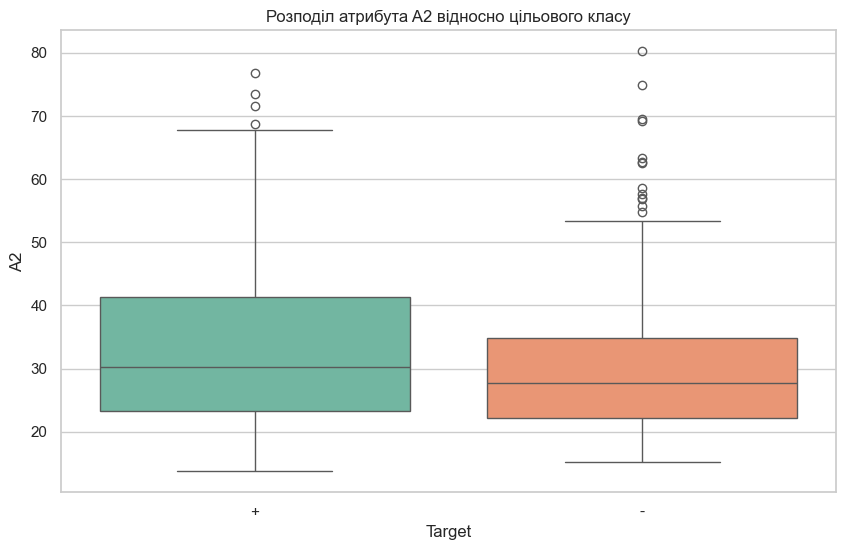

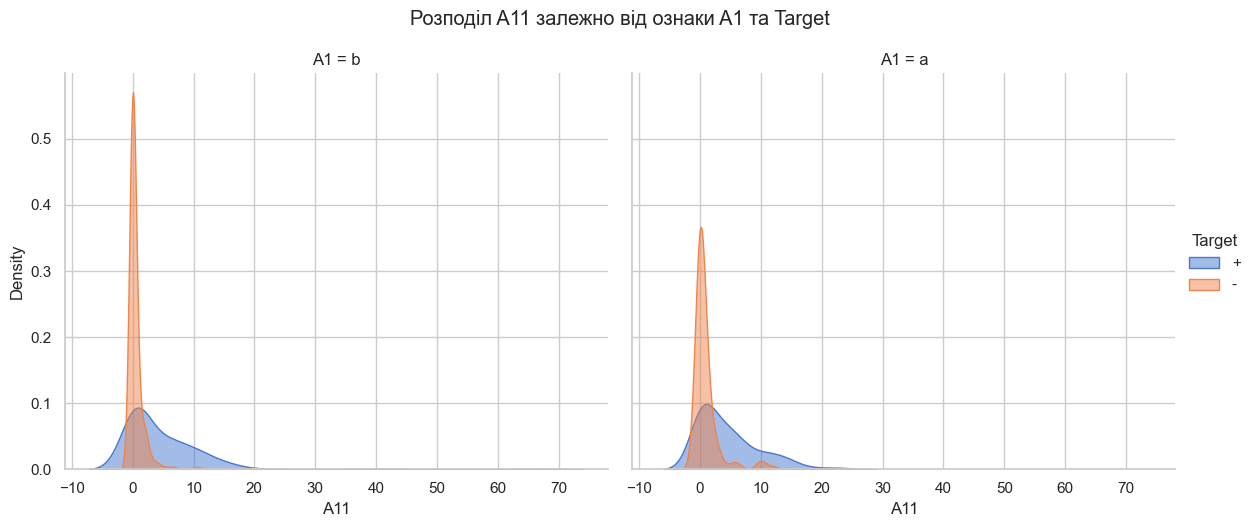

In [12]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Target', palette='pastel')
plt.title('Баланс цільового класу (Approval: + / -)')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Target', y='A2', palette='Set2')
plt.title('Розподіл атрибута A2 відносно цільового класу')
plt.show()

g = sns.FacetGrid(df, col="A1", hue="Target", height=5, aspect=1.2)
g.map(sns.kdeplot, "A11", fill=True, alpha=0.5)
g.add_legend()
g.fig.suptitle('Розподіл A11 залежно від ознаки A1 та Target', y=1.05)
plt.show()